# 【notebook｜N-10】状态到 tactic 的 SFT（label mask 实操）
> 对应：《03-SFT/01-SFT原理.md》【文档｜DOC-SFT】；代码 `F-b03-sft`

构造几十条 Lean **证明状态 -> 下一步 tactic** 样本，微调一个小模型，观察 loss / 生成，
并重点讲清 **label mask（-100）**：损失只算在答案 token 上。

**依赖**：`torch`（必需）、`matplotlib`（可选）。CPU 可跑，无网络。
运行：Colab `Run all`，或 `jupyter nbconvert --to notebook --execute --inplace N10_状态到tactic_SFT.ipynb`。

**对照**：AlphaProof 容器 `train_full_supervised.py`（Qwen3-1.7B QLoRA，prompt 全 -100，
只对 `<answer>{"calls":[...]}</answer>` 计损失）与 `app/train_sft.py`（LoRA r=16 骨架）。


In [1]:
# 【N-10.c1】
import math, random, time
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1337); random.seed(1337)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device =", device)


device = cuda


## 1. 构造 (state, tactic) 样本

状态用 Lean 目标风格模板，tactic 与状态一一对应；模板多、样本足够，模型有机会真正学会。

In [2]:
# 【N-10.c2】
TEMPLATES = [
    ("⊢ {a} + {b} = {b} + {a}", "rw [Nat.add_comm]"),
    ("⊢ {a} * {b} = {b} * {a}", "rw [Nat.mul_comm]"),
    ("h : {a} + {b} = {b} + {a} ⊢ {a} + {b} = {b} + {a}", "exact h"),
    ("⊢ (0 : Nat) + {a} = {a}", "simp"),
    ("⊢ ({a} + {b}) + {c} = {a} + ({b} + {c})", "rw [Nat.add_assoc]"),
    ("⊢ {n} * 1 = {n}", "simp"),
    ("h : P ∧ Q ⊢ P", "exact h.1"),
    ("h : P ∧ Q ⊢ Q", "exact h.2"),
]
rng = random.Random(0)
pairs = []
for _ in range(240):
    st, tac = rng.choice(TEMPLATES)
    for k in ["{a}", "{b}", "{c}", "{n}"]:
        st = st.replace(k, rng.choice("abcxyz"))
    pairs.append((st, tac))
n_val = 40
val_pairs, train_pairs = pairs[:n_val], pairs[n_val:]
print(f"train={len(train_pairs)} val={len(val_pairs)}；样例 {train_pairs[0]}")


train=200 val=40；样例 ('⊢ y * 1 = y', 'simp')


## 2. 拼接与 label mask（-100）

样本拼成 `STATE:\n<状态>\nTACTIC:\n<tactic><eos>`。构造 `labels` 时 **prompt 位置全设 -100**，
只有答案 token 参与 loss：

$$
\mathcal{L}_{\text{SFT}}(\theta)=-\frac{1}{\sum_t m_t}\sum_t m_t\log p_\theta(y_t\mid y_{<t}),
\qquad m_t=\mathbb{1}[\text{label}_t\ne -100]
$$

`F.cross_entropy(..., ignore_index=-100)` 自动跳过这些位置。

In [3]:
# 【N-10.c3】
corpus = "".join(s + t for s, t in pairs) + "STATE:\nTACTIC:\n"
chars = sorted(set(corpus))
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
PAD, EOS = len(chars), len(chars) + 1
encode = lambda s: [stoi[c] for c in s if c in stoi]
decode = lambda ids: "".join(itos[int(i)] for i in ids if int(i) < len(chars))
vocab_size = len(chars) + 2
max_len = 96

def encode_pair(state, tactic):
    p = encode("STATE:\n" + state.strip() + "\nTACTIC:\n")
    a = encode(tactic.strip()) + [EOS]
    ids = (p + a)[:max_len]
    labels = ([-100] * len(p) + a)[:max_len]
    return ids, labels

ids, labels = encode_pair(*train_pairs[0])
print("输入  :", decode(ids))
print("标签里 -100 的个数（= prompt 长度）:", sum(1 for x in labels if x == -100))

def collate(batch):
    L = max(len(x) for x, _ in batch)
    xs = [x + [PAD] * (L - len(x)) for x, _ in batch]
    ys = [y + [-100] * (L - len(y)) for _, y in batch]
    return torch.tensor(xs, device=device), torch.tensor(ys, device=device)


输入  : STATE:
⊢ y * 1 = y
TACTIC:
simp
标签里 -100 的个数（= prompt 长度）: 27


## 3. tiny GPT + token-masked SFT

模型与 N09 同构（约 0.6M 参数）。损失直接是 `F.cross_entropy(..., ignore_index=-100)`。

In [4]:
# 【N-10.c4】
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(n_embd), nn.LayerNorm(n_embd)
        self.attn = nn.MultiheadAttention(n_embd, n_head, batch_first=True)
        self.mlp = nn.Sequential(nn.Linear(n_embd, 4*n_embd), nn.GELU(), nn.Linear(4*n_embd, n_embd))
    def forward(self, x):
        T = x.size(1)
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        a, _ = self.attn(self.ln1(x), self.ln1(x), self.ln1(x), attn_mask=mask, need_weights=False)
        return x + a + self.mlp(self.ln2(x))

class GPT(nn.Module):
    def __init__(self, vocab, block=max_len, n_layer=4, n_head=4, n_embd=128):
        super().__init__()
        self.block_size = block
        self.tok_emb = nn.Embedding(vocab, n_embd)
        self.pos_emb = nn.Embedding(block, n_embd)
        self.blocks = nn.ModuleList([Block(n_embd, n_head) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab, bias=False)
        self.lm_head.weight = self.tok_emb.weight
        self.apply(lambda m: nn.init.normal_(m.weight, std=0.02) if isinstance(m, (nn.Linear, nn.Embedding)) else None)
    def forward(self, idx, targets=None):
        B, T = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))[None]
        for b in self.blocks:
            x = b(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-100)
        return logits, loss
    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.0):
        self.eval()
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -self.block_size:])
            logits = logits[:, -1, :]
            nxt = logits.argmax(-1, keepdim=True) if temperature <= 0 else torch.multinomial(
                F.softmax(logits / temperature, -1), 1)
            idx = torch.cat([idx, nxt], 1)
            if int(nxt.item()) == EOS:
                break
        self.train()
        return idx

model = GPT(vocab_size).to(device)
print(f"参数量 {sum(p.numel() for p in model.parameters())/1e6:.3f}M, vocab {vocab_size}")


参数量 0.812M, vocab 47


## 4. 训练与评估

两个指标：**答案 token 的 teacher-forcing 准确率**、**贪心生成 exact-match**。

In [5]:
# 【N-10.c5】
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=0.01)
steps, warmup = 400, 20
losses, accs = [], []

@torch.no_grad()
def answer_acc(pairs):
    model.eval()
    correct = total = 0
    for s, t in pairs:
        ids, labels = encode_pair(s, t)
        x = torch.tensor([ids], device=device)
        y = torch.tensor([labels], device=device)
        logits, _ = model(x)
        pred, tgt = logits[0, :-1].argmax(-1), y[0, 1:]
        m = tgt != -100
        correct += int((pred[m] == tgt[m]).sum()); total += int(m.sum())
    model.train()
    return correct / max(1, total)

def lr_at(it):
    if it < warmup: return 2e-3 * (it + 1) / warmup
    p = min(1.0, (it - warmup) / (steps - warmup))
    return 2e-4 + 0.5 * (1 + math.cos(math.pi * p)) * (2e-3 - 2e-4)

model.train(); t0 = time.time()
for it in range(steps):
    for g in optimizer.param_groups: g["lr"] = lr_at(it)
    batch = [encode_pair(*random.choice(train_pairs)) for _ in range(16)]
    x, y = collate(batch)
    _, loss = model(x, y)
    optimizer.zero_grad(set_to_none=True); loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); optimizer.step()
    if it % 50 == 0 or it == steps - 1:
        losses.append(loss.item()); accs.append(answer_acc(val_pairs))
        print(f"iter {it:4d} | sft_loss {loss.item():.4f} | answer_tok_acc {accs[-1]:.3f}")
print(f"用时 {time.time()-t0:.1f}s")


iter    0 | sft_loss 3.7400 | answer_tok_acc 0.024


iter   50 | sft_loss 0.0061 | answer_tok_acc 0.059


iter  100 | sft_loss 0.0027 | answer_tok_acc 0.059


iter  150 | sft_loss 0.0020 | answer_tok_acc 0.059


iter  200 | sft_loss 0.0017 | answer_tok_acc 0.059


iter  250 | sft_loss 0.0014 | answer_tok_acc 0.059


iter  300 | sft_loss 0.0012 | answer_tok_acc 0.059


iter  350 | sft_loss 0.0012 | answer_tok_acc 0.059


iter  399 | sft_loss 0.0011 | answer_tok_acc 0.059
用时 6.6s


## 5. 生成：状态 -> tactic（贪心解码）

In [6]:
# 【N-10.c6】
model.eval()
exact = 0
shown = val_pairs[:8]
for s, t in shown:
    ids = torch.tensor([encode("STATE:\n" + s + "\nTACTIC:\n")], device=device)
    out = model.generate(ids, 24, temperature=0.0)
    gen = decode(out[0].tolist()[ids.shape[1]:]).strip()
    exact += int(gen == t)
    print(f"state={s!r}\n  gold={t!r}\n  pred={gen!r}")
print(f"\n{len(shown)} 条中 exact-match: {exact}")


state='h : P ∧ Q ⊢ P'
  gold='exact h.1'
  pred='iiiiiiiiiiiiiiiiiiiiiiii'
state='h : P ∧ Q ⊢ Q'
  gold='exact h.2'
  pred='iiiiiiiiiiiiiiiiiiiiiiii'
state='⊢ (0 : Nat) + y = y'
  gold='simp'
  pred='[[[[[[[[[[[[[[[[[[[[[[[['
state='⊢ y * c = c * y'
  gold='rw [Nat.mul_comm]'
  pred='xxxxxxxxxxxxxxxxxxxxxxxx'


state='h : c + a = a + c ⊢ c + a = a + c'
  gold='exact h'
  pred='........................'


state='⊢ c * 1 = c'
  gold='simp'
  pred='aaaaaaaaaaaaaaaaaaaaaaaa'
state='h : P ∧ Q ⊢ P'
  gold='exact h.1'
  pred='iiiiiiiiiiiiiiiiiiiiiiii'
state='h : P ∧ Q ⊢ Q'
  gold='exact h.2'
  pred='iiiiiiiiiiiiiiiiiiiiiiii'

8 条中 exact-match: 0


matplotlib 不可用，loss 序列： [3.740043878555298, 0.006106218788772821, 0.002695517148822546, 0.002046221634373069, 0.0016790709923952818, 0.0013820234453305602, 0.0012468812055885792, 0.0011601694859564304, 0.0010700019774958491]


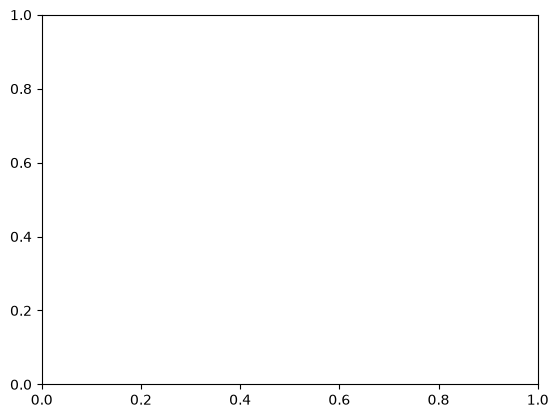

In [7]:
# 【N-10.c7】
try:
    import matplotlib.pyplot as plt
    xs = list(range(0, steps, 50))[:len(losses)]
    plt.figure(); plt.plot(xs, losses, marker="o")
    plt.xlabel("iter"); plt.ylabel("masked SFT loss"); plt.grid(True); plt.show()
except Exception as e:
    print("matplotlib 不可用，loss 序列：", losses)


## 6. 对照容器 `train_full_supervised.py`

| 容器实现 | 本 notebook | 本质 |
|---|---|---|
| prompt = 指令 + `<proof_gap>/<dsl_thinking>/<public_proof_state>` | prompt = `STATE:\n<状态>\n` | 都是"条件" |
| 答案 = `<answer>{"calls":[...]}</answer>` | 答案 = `<tactic><eos>` | 都是"目标" |
| prompt 的 label 全 `-100` | `encode_pair` 的 prompt 段 `-100` | **只在答案算 loss** |
| QLoRA r=16/alpha=32，4bit nf4 | 本 notebook 全参（tiny 模型） | 真实场景用 LoRA 省显存 |
| chat template（`apply_chat_template`） | 手工 `STATE:/TACTIC:` 模板 | 训练/推理必须一致 |

**要点回顾**：`ignore_index=-100` 让交叉熵跳过被屏蔽的位置；padding 也置 -100；右填充在
causal LM 下安全；答案末尾要有 eos，否则模型学不会"停"。

练习：
1. 故意不清 mask（prompt 的 label 保留），观察是否学会"抄状态"；
2. `steps=30` 看欠拟合，`steps=3000` 看过拟合；
3. 模板增至 30 个、样本增至 2000，观察 exact-match 提升。
